In [1]:
import os
import random
import torchvision
import torchvision.transforms.functional as TF
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
import torch
import segmentation_models_pytorch as smp
import numpy as np


/home/godwinkhalko/deformable-detr-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class ISRODataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, augment=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.augment = augment

        # Sort both lists to guarantee alignment between image and mask
        self.image_paths = sorted([
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir) if f.endswith('.tiff')
        ])
        self.mask_paths = sorted([
            os.path.join(mask_dir, f)
            for f in os.listdir(mask_dir) if f.endswith('.png')
        ])

        assert len(self.image_paths) == len(self.mask_paths), \
            f"Mismatch: {len(self.image_paths)} images vs {len(self.mask_paths)} masks"

    def __len__(self):
        return len(self.image_paths)

    def apply_shared_augmentations(self, image, mask):
        """
        Spatial augmentations must be applied IDENTICALLY to both
        image and mask. We use TF (transforms.functional) with a
        shared random seed so both get the exact same transformation.
        """
        # Random horizontal flip
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        # Random vertical flip
        if random.random() > 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        return image, mask

    def __getitem__(self, idx):
        # --- Load ---
        image = Image.open(self.image_paths[idx]).convert('L')  # Grayscale
        mask = Image.open(self.mask_paths[idx]).convert('L')    # Grayscale

        # --- Resize both (spatial, must match) ---
        resize = torchvision.transforms.Resize((256, 256))
        image = resize(image)
        mask = resize(mask)

        # --- Synchronized spatial augmentations ---
        if self.augment:
            image, mask = self.apply_shared_augmentations(image, mask)

        # --- Image-only augmentations (never apply to mask) ---
        if self.augment:
            if random.random() > 0.5:
                image = TF.gaussian_blur(image, kernel_size=[5, 9], sigma=[0.1, 5.0])
            if random.random() > 0.5:
                # ColorJitter contrast only — safe for grayscale X-rays
                image = torchvision.transforms.ColorJitter(contrast=0.5)(image)

        # --- To tensor ---
        image = TF.to_tensor(image)   # Shape: [1, H, W], values in [0, 1]
        mask = TF.to_tensor(mask)     # Shape: [1, H, W], values in [0, 1]

        # --- Normalize image ONLY, after all augmentations ---
        image = TF.normalize(image, mean=[0.485], std=[0.229])

        # --- Binarize mask: make it strictly 0 or 1 ---
        mask = (mask > 0.5).float()   # [1, H, W] with values {0.0, 1.0}

        return image, mask

In [ ]:
# Create an instance of the dataset
train_dataset = ISRODataset(
    image_dir='/home/godwinkhalko/ISRO/VOID_DATA/train_images',
    mask_dir='/home/godwinkhalko/ISRO/VOID_DATA/train_annotations',
    augment=True      # augment=False for val/test
)

val_dataset = ISRODataset(
    image_dir='/home/godwinkhalko/ISRO/VOID_DATA/val_images',
    mask_dir='/home/godwinkhalko/ISRO/VOID_DATA/val_annotations',
    augment=False
)

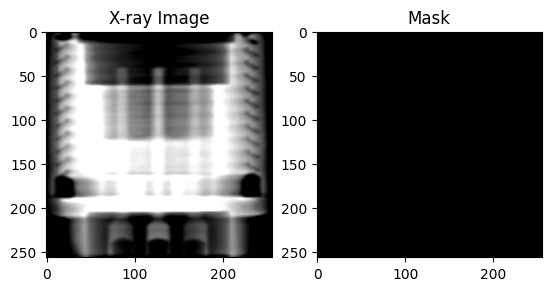

Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Mask unique values: tensor([0.])


In [12]:
image, mask = train_dataset[342]

fig, axes = plt.subplots(1, 2)
axes[0].imshow(image.squeeze(), cmap='gray')
axes[0].set_title('X-ray Image')
axes[1].imshow(mask.squeeze(), cmap='gray')
axes[1].set_title('Mask')
plt.show()

print("Image shape:", image.shape)   # Expected: [1, 256, 256]
print("Mask shape:", mask.shape)     # Expected: [1, 256, 256]
print("Mask unique values:", mask.unique())  # Expected: tensor([0., 1.])

In [13]:
model = smp.Unet(
    encoder_name="resnet34",   # backbone
    encoder_weights="imagenet",  # pretrained
    in_channels=1,  # X-ray = grayscale
    classes=1       # binary segmentation
)

In [14]:
#Loss Functions
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

#Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss()(inputs, targets)
        pt = torch.exp(-BCE_loss)  # prevents nans when probability 0
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return F_loss.mean()
    
#loss function
def loss_fn(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

In [15]:
#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [16]:
#Training loop
def train_model(model, train_loader, val_loader, optimizer, num_epochs=10, device='cuda:0'):
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            print(f"Epoch [{epoch+1}/{num_epochs}] - Batch Loss: {loss.item():.4f}")
        avg_train_loss = train_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Average Train Loss: {avg_train_loss:.4f}")
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}] Val Loss: {avg_val_loss:.4f}")

In [17]:
#Create DataLoaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [10]:
#Start Training
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
model.to(device)
train_model(model, train_loader, val_loader, optimizer, num_epochs=1, device=device)

Epoch [1/1] - Batch Loss: 1.7614
Epoch [1/1] - Batch Loss: 1.7520
Epoch [1/1] - Batch Loss: 1.7358
Epoch [1/1] - Batch Loss: 1.7160
Epoch [1/1] - Batch Loss: 1.6992
Epoch [1/1] - Batch Loss: 1.6815
Epoch [1/1] - Batch Loss: 1.6693
Epoch [1/1] - Batch Loss: 1.6412
Epoch [1/1] - Batch Loss: 1.6226
Epoch [1/1] - Batch Loss: 1.6036
Epoch [1/1] - Batch Loss: 1.5997
Epoch [1/1] - Batch Loss: 1.5761
Epoch [1/1] - Batch Loss: 1.5666
Epoch [1/1] - Batch Loss: 1.5459
Epoch [1/1] - Batch Loss: 1.5410
Epoch [1/1] - Batch Loss: 1.5222
Epoch [1/1] - Batch Loss: 1.5125
Epoch [1/1] - Batch Loss: 1.5095
Epoch [1/1] - Batch Loss: 1.4975
Epoch [1/1] - Batch Loss: 1.4887
Epoch [1/1] - Batch Loss: 1.4812
Epoch [1/1] - Batch Loss: 1.4739
Epoch [1/1] - Batch Loss: 1.4555
Epoch [1/1] - Batch Loss: 1.4527
Epoch [1/1] - Batch Loss: 1.4483
Epoch [1/1] - Batch Loss: 1.4314
Epoch [1/1] - Batch Loss: 1.4247
Epoch [1/1] - Batch Loss: 1.4225
Epoch [1/1] - Batch Loss: 1.4089
Epoch [1/1] - Batch Loss: 1.4142
Epoch [1/1

In [18]:
#clear GPUs
torch.cuda.empty_cache()
del model
del optimizer


In [19]:
del train_loader
del val_loader
del train_dataset
del val_dataset

In [2]:
len(os.listdir('/home/godwinkhalko/ISRO/Data/val_images')), len(os.listdir('/home/godwinkhalko/ISRO/Data/val_masks'))   

(282, 282)

## Testing Metrics


In [1]:
import os
import random
import torchvision
import torchvision.transforms.functional as TF
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
import torch
import segmentation_models_pytorch as smp
import numpy as np


/home/godwinkhalko/deformable-detr-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
checkpoint = "/home/godwinkhalko/ISRO/CodeBase/UNetPP/isro_unetplusplus_resnet34_DATA.pth"

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = smp.UnetPlusPlus(
    encoder_name="resnet34",   # backbone
    encoder_weights="imagenet",  # pretrained
    in_channels=1,  # X-ray = grayscale
    classes=1       # binary segmentation
    )
model.load_state_dict(torch.load(checkpoint, map_location='cpu'))
model.to(device)
model.eval()  # Set to evaluation mode
#iterate through validation images and predict masks
model.eval()



UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [23]:
#Check the IOU metric for the predicted masks and the original masks
import cv2
import torch
def iou(pred, target, eps=1e-6,):
    target = (target > 0).float()
    inter = (pred * target).sum()
    union = (pred + target).sum() - inter

    return (inter + eps) / (union + eps)

#Dice Coefficient
def dice_coeff(pred, target, eps=1e-6):
    target = (target > 0).float()

    inter = (pred * target).sum()
    return (2 * inter + eps) / (pred.sum() + target.sum() + eps)

#Precision and Recall
def precision(pred, target, eps=1e-6):
    target = (target > 0).float()

    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()

    return (tp + eps) / (tp + fp + eps)
def recall(pred, target, eps=1e-6):
    target = (target > 0).float()

    tp = (pred * target).sum()
    fn = ((1 - pred) * target).sum()

    return (tp + eps) / (tp + fn + eps)

resize = torchvision.transforms.Resize((256, 256))
#check the files names in validation set
val_images = "/home/godwinkhalko/ISRO/DATA/val_images"
val_masks = "/home/godwinkhalko/ISRO/Annotated/binary_masks"

#Create lists of image names for batch and non-batch images
val_image_names = [f for f in os.listdir(val_images) if f.endswith('.tiff')]
val_image_batch_names = [f for f in os.listdir(val_images) if f.endswith('.tiff') and f.startswith('Batch')]
val_image_non_batch_names = [f for f in os.listdir(val_images) if f.endswith('.tiff') and not f.startswith('Batch')]



In [24]:
img_name = val_image_names[0]
  # Example: take the first image for testing
img_path = os.path.join(val_images, img_name)

image = Image.open(img_path).convert('L')
image = resize(image)
image_tensor = TF.to_tensor(image)
image_tensor = TF.normalize(image_tensor, mean=[0.485], std=[0.229])
image_tensor = image_tensor.unsqueeze(0).to(device)

## Metrics on Images with Voids

In [28]:
#Iterate through validation images and calculate IOU for each
ious = []
dice_coeffs = []
precisions = []
recalls = []
resize = torchvision.transforms.Resize((256, 256))
thresholds = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
metrics_voids = {}
for threshold in thresholds:
    ious = []
    dice_coeffs = []
    precisions = []
    recalls = []
    for img_name in val_image_batch_names:
        img_path = os.path.join(val_images, img_name)

        image = Image.open(img_path).convert('L')
        image = resize(image)
        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, mean=[0.485], std=[0.229])
        image_tensor = image_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            pred_mask = torch.sigmoid(output).cpu()  # keep as tensor
            pred_mask = (pred_mask > threshold).float()
            kernel = np.ones((3,3), np.uint8)
            pred_mask = cv2.dilate(pred_mask.numpy().squeeze(), kernel)
            pred_mask = torch.from_numpy(pred_mask).unsqueeze(0).unsqueeze(0).float()  # back to tensor with shape [1, 1, H, W]
        # Load mask
        mask_name = img_name.replace('.tiff', '.png')
        mask_path = os.path.join(val_masks, mask_name)

        original_mask = Image.open(mask_path).convert('L')
        original_mask = resize(original_mask)
        original_mask = TF.to_tensor(original_mask)  # stays tensor
        
        # Compute IoU
        iou_val = iou(pred_mask.squeeze(), original_mask.squeeze())
        ious.append(iou_val.item())
        # Compute Dice Coefficient
        dice_val = dice_coeff(pred_mask.squeeze(), original_mask.squeeze())
        dice_coeffs.append(dice_val.item())
        precision_val = precision(pred_mask.squeeze(), original_mask.squeeze())
        precisions.append(precision_val.item())
        recall_val = recall(pred_mask.squeeze(), original_mask.squeeze())
        recalls.append(recall_val.item())

        # print(f"Image: {img_name}, IOU: {iou_val:.4f}, Dice Coeff: {dice_val:.4f}")
    print(f"Metrics for Threshold: {threshold:.2f}")
    print(f"Mean IOU: {np.mean(ious):.4f}")
    print(f"Mean Dice Coefficient: {np.mean(dice_coeffs):.4f}")
    print(f"Mean Precision: {np.mean(precisions):.4f}")
    print(f"Mean Recall: {np.mean(recalls):.4f}")
    metrics_voids[threshold] = {
        'iou': np.mean(ious),
        'dice': np.mean(dice_coeffs),
        'precision': np.mean(precisions),
        'recall': np.mean(recalls)
    }

Metrics for Threshold: 0.01
Mean IOU: 0.6375
Mean Dice Coefficient: 0.7655
Mean Precision: 0.7024
Mean Recall: 0.8942
Metrics for Threshold: 0.05
Mean IOU: 0.6480
Mean Dice Coefficient: 0.7734
Mean Precision: 0.7322
Mean Recall: 0.8707
Metrics for Threshold: 0.10
Mean IOU: 0.6511
Mean Dice Coefficient: 0.7758
Mean Precision: 0.7436
Mean Recall: 0.8610
Metrics for Threshold: 0.15
Mean IOU: 0.6520
Mean Dice Coefficient: 0.7765
Mean Precision: 0.7498
Mean Recall: 0.8549
Metrics for Threshold: 0.20
Mean IOU: 0.6526
Mean Dice Coefficient: 0.7770
Mean Precision: 0.7542
Mean Recall: 0.8506
Metrics for Threshold: 0.25
Mean IOU: 0.6528
Mean Dice Coefficient: 0.7771
Mean Precision: 0.7579
Mean Recall: 0.8465
Metrics for Threshold: 0.30
Mean IOU: 0.6527
Mean Dice Coefficient: 0.7771
Mean Precision: 0.7608
Mean Recall: 0.8428
Metrics for Threshold: 0.35
Mean IOU: 0.6529
Mean Dice Coefficient: 0.7773
Mean Precision: 0.7637
Mean Recall: 0.8399
Metrics for Threshold: 0.40
Mean IOU: 0.6532
Mean Dice C

## Metrics on all Images

In [31]:
ious = []
dice_coeffs = []
precisions = []
recalls = []
resize = torchvision.transforms.Resize((256, 256))
thresholds = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
metrics_voids = {}
for threshold in thresholds:
    ious = []
    dice_coeffs = []
    precisions = []
    recalls = []
    for img_name in val_image_names:
        img_path = os.path.join(val_images, img_name)

        image = Image.open(img_path).convert('L')
        image = resize(image)
        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, mean=[0.485], std=[0.229])
        image_tensor = image_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            pred_mask = torch.sigmoid(output).cpu()  # keep as tensor
            pred_mask = (pred_mask > threshold).float()
            kernel = np.ones((3,3), np.uint8)
            pred_mask = cv2.dilate(pred_mask.numpy().squeeze(), kernel)
            pred_mask = torch.from_numpy(pred_mask).unsqueeze(0).unsqueeze(0).float()  # back to tensor with shape [1, 1, H, W]
        # Load mask
        mask_name = img_name.replace('.tiff', '.png')
        mask_path = os.path.join(val_masks, mask_name)

        original_mask = Image.open(mask_path).convert('L')
        original_mask = resize(original_mask)
        original_mask = TF.to_tensor(original_mask)  # stays tensor

        # Compute IoU
        iou_val = iou(pred_mask.squeeze(), original_mask.squeeze())
        ious.append(iou_val.item())
        # Compute Dice Coefficient
        dice_val = dice_coeff(pred_mask.squeeze(), original_mask.squeeze())
        dice_coeffs.append(dice_val.item())
        precision_val = precision(pred_mask.squeeze(), original_mask.squeeze())
        precisions.append(precision_val.item())
        recall_val = recall(pred_mask.squeeze(), original_mask.squeeze())
        recalls.append(recall_val.item())

        # print(f"Image: {img_name}, IOU: {iou_val:.4f}, Dice Coeff: {dice_val:.4f}")
    print(f"Metrics for Threshold: {threshold:.2f}")
    print(f"Mean IOU: {np.mean(ious):.4f}")
    print(f"Mean Dice Coefficient: {np.mean(dice_coeffs):.4f}")
    print(f"Mean Precision: {np.mean(precisions):.4f}")
    print(f"Mean Recall: {np.mean(recalls):.4f}")
    metrics_voids[threshold] = {
        'iou': np.mean(ious),
        'dice': np.mean(dice_coeffs),
        'precision': np.mean(precisions),
        'recall': np.mean(recalls)
    }

Metrics for Threshold: 0.01
Mean IOU: 0.7553
Mean Dice Coefficient: 0.8418
Mean Precision: 0.8005
Mean Recall: 0.9251
Metrics for Threshold: 0.05
Mean IOU: 0.7623
Mean Dice Coefficient: 0.8471
Mean Precision: 0.8204
Mean Recall: 0.9096
Metrics for Threshold: 0.10
Mean IOU: 0.7643
Mean Dice Coefficient: 0.8486
Mean Precision: 0.8281
Mean Recall: 0.9030
Metrics for Threshold: 0.15
Mean IOU: 0.7648
Mean Dice Coefficient: 0.8490
Mean Precision: 0.8321
Mean Recall: 0.8989
Metrics for Threshold: 0.20
Mean IOU: 0.7652
Mean Dice Coefficient: 0.8493
Mean Precision: 0.8350
Mean Recall: 0.8961
Metrics for Threshold: 0.25
Mean IOU: 0.7653
Mean Dice Coefficient: 0.8494
Mean Precision: 0.8375
Mean Recall: 0.8934
Metrics for Threshold: 0.30
Mean IOU: 0.7652
Mean Dice Coefficient: 0.8494
Mean Precision: 0.8394
Mean Recall: 0.8909
Metrics for Threshold: 0.35
Mean IOU: 0.7652
Mean Dice Coefficient: 0.8494
Mean Precision: 0.8412
Mean Recall: 0.8889
Metrics for Threshold: 0.40
Mean IOU: 0.7653
Mean Dice C

## Metrics on non-void images


In [14]:
ious = []
dice_coeffs = []
precisions = []
recalls = []
resize = torchvision.transforms.Resize((256, 256))
thresholds = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
metrics_voids = {}
for threshold in thresholds:
    ious = []
    dice_coeffs = []
    precisions = []
    recalls = []
    for img_name in val_image_non_batch_names:
        img_path = os.path.join(val_images, img_name)

        image = Image.open(img_path).convert('L')
        image = resize(image)
        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, mean=[0.485], std=[0.229])
        image_tensor = image_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            pred_mask = torch.sigmoid(output).cpu()  # keep as tensor
            pred_mask = (pred_mask > threshold).float()
            kernel = np.ones((3,3), np.uint8)
            pred_mask = cv2.dilate(pred_mask.numpy().squeeze(), kernel)
            pred_mask = torch.from_numpy(pred_mask).unsqueeze(0).unsqueeze(0).float()  # back to tensor with shape [1, 1, H, W]
        # Load mask
        mask_name = img_name.replace('.tiff', '_binary_mask.png')
        mask_path = os.path.join(val_masks, mask_name)

        original_mask = Image.open(mask_path).convert('L')
        original_mask = resize(original_mask)
        original_mask = TF.to_tensor(original_mask)  # stays tensor

        # Compute IoU
        iou_val = iou(pred_mask.squeeze(), original_mask.squeeze())
        ious.append(iou_val.item())
        # Compute Dice Coefficient
        dice_val = dice_coeff(pred_mask.squeeze(), original_mask.squeeze())
        dice_coeffs.append(dice_val.item())
        precision_val = precision(pred_mask.squeeze(), original_mask.squeeze())
        precisions.append(precision_val.item())
        recall_val = recall(pred_mask.squeeze(), original_mask.squeeze())
        recalls.append(recall_val.item())

        # print(f"Image: {img_name}, IOU: {iou_val:.4f}, Dice Coeff: {dice_val:.4f}")
    print(f"Metrics for Threshold: {threshold:.2f}")
    print(f"Mean IOU: {np.mean(ious):.4f}")
    print(f"Mean Dice Coefficient: {np.mean(dice_coeffs):.4f}")
    print(f"Mean Precision: {np.mean(precisions):.4f}")
    print(f"Mean Recall: {np.mean(recalls):.4f}")
    metrics_voids[threshold] = {
        'iou': np.mean(ious),
        'dice': np.mean(dice_coeffs),
        'precision': np.mean(precisions),
        'recall': np.mean(recalls)
    }

Metrics for Threshold: 0.01
Mean IOU: 0.9472
Mean Dice Coefficient: 0.9668
Mean Precision: 0.9610
Mean Recall: 0.9777
Metrics for Threshold: 0.05
Mean IOU: 0.9478
Mean Dice Coefficient: 0.9675
Mean Precision: 0.9658
Mean Recall: 0.9731
Metrics for Threshold: 0.10
Mean IOU: 0.9475
Mean Dice Coefficient: 0.9673
Mean Precision: 0.9673
Mean Recall: 0.9713
Metrics for Threshold: 0.15
Mean IOU: 0.9472
Mean Dice Coefficient: 0.9671
Mean Precision: 0.9681
Mean Recall: 0.9699
Metrics for Threshold: 0.20
Mean IOU: 0.9468
Mean Dice Coefficient: 0.9669
Mean Precision: 0.9687
Mean Recall: 0.9689
Metrics for Threshold: 0.25
Mean IOU: 0.9466
Mean Dice Coefficient: 0.9667
Mean Precision: 0.9690
Mean Recall: 0.9682
Metrics for Threshold: 0.30
Mean IOU: 0.9464
Mean Dice Coefficient: 0.9666
Mean Precision: 0.9694
Mean Recall: 0.9676
Metrics for Threshold: 0.35
Mean IOU: 0.9462
Mean Dice Coefficient: 0.9664
Mean Precision: 0.9697
Mean Recall: 0.9670
Metrics for Threshold: 0.40
Mean IOU: 0.9460
Mean Dice C

## Visualization

In [9]:
#Check the IOU metric for the predicted masks and the original masks
import cv2
import torch
def iou(pred, target, eps=1e-6,):
    target = (target > 0).float()
    inter = (pred * target).sum()
    union = (pred + target).sum() - inter

    return (inter + eps) / (union + eps)

#Dice Coefficient
def dice_coeff(pred, target, eps=1e-6):
    target = (target > 0).float()

    inter = (pred * target).sum()
    return (2 * inter + eps) / (pred.sum() + target.sum() + eps)

#Precision and Recall
def precision(pred, target, eps=1e-6):
    target = (target > 0).float()

    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()

    return (tp + eps) / (tp + fp + eps)
def recall(pred, target, eps=1e-6):
    target = (target > 0).float()

    tp = (pred * target).sum()
    fn = ((1 - pred) * target).sum()

    return (tp + eps) / (tp + fn + eps)

#Iterate through validation images and calculate IOU for each
#check the files names in validation set
val_images = "/home/godwinkhalko/ISRO/VOID_DATA/val_images" 
val_masks = "/home/godwinkhalko/ISRO/VOID_DATA/val_annotations"
val_image_names = [f for f in os.listdir(val_images) if f.endswith('.png') and f.startswith('Batch')]
resize = torchvision.transforms.Resize((256, 256))
threshold = 0.10
results = []

for img_name in val_image_names:
    img_path = os.path.join(val_images, img_name)

    image = Image.open(img_path).convert('L')
    image = resize(image)
    image_tensor = TF.to_tensor(image)
    image_tensor = TF.normalize(image_tensor, mean=[0.485], std=[0.229])
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        pred_mask = torch.sigmoid(output).cpu()  # keep as tensor
        pred_mask = (pred_mask > threshold).float()
        kernel = np.ones((3,3), np.uint8)
        pred_mask = cv2.dilate(pred_mask.numpy().squeeze(), kernel)
        pred_mask = torch.from_numpy(pred_mask).unsqueeze(0).unsqueeze(0).float()  # back to tensor with shape [1, 1, H, W]
    # Load mask
    mask_name = img_name.replace('.tiff', '.png')
    mask_path = os.path.join(val_masks, mask_name)

    original_mask = Image.open(mask_path).convert('L')
    original_mask = resize(original_mask)
    original_mask = TF.to_tensor(original_mask)  # stays tensor

    # Compute IoU
    iou_val = iou(pred_mask.squeeze(), original_mask.squeeze())
    # Compute Dice Coefficient
    dice_val = dice_coeff(pred_mask, original_mask.squeeze())
    precision_val = precision(pred_mask.squeeze(), original_mask.squeeze())
    recall_val = recall(pred_mask.squeeze(), original_mask.squeeze())
    results.append({
        'image': img_name,
        'iou': iou_val.item(),
        'dice': dice_val.item(),
        'precision': precision_val.item(),
        'recall': recall_val.item(),
        'mask': pred_mask.squeeze().numpy()  # Store the predicted mask for later analysis
    })

In [21]:
mean_iou= np.mean([res['iou'] for res in results])
mean_dice = np.mean([res['dice'] for res in results])
mean_precision = np.mean([res['precision'] for res in results])
mean_recall = np.mean([res['recall'] for res in results])
print(f"Mean IOU: {mean_iou:.4f}")
print(f"Mean Dice Coefficient: {mean_dice:.4f}")
print(f"Mean Precision: {mean_precision:.4f}")
print(f"Mean Recall: {mean_recall:.4f}")

Mean IOU: 0.3605
Mean Dice Coefficient: 0.5060
Mean Precision: 0.4744
Mean Recall: 0.6942


In [ ]:
#Sort the results by perfromance (e.g., by Dice Coefficient)
results = sorted(results, key=lambda x: x['dice'], reverse=True)

In [19]:
worst_results = results[:20]

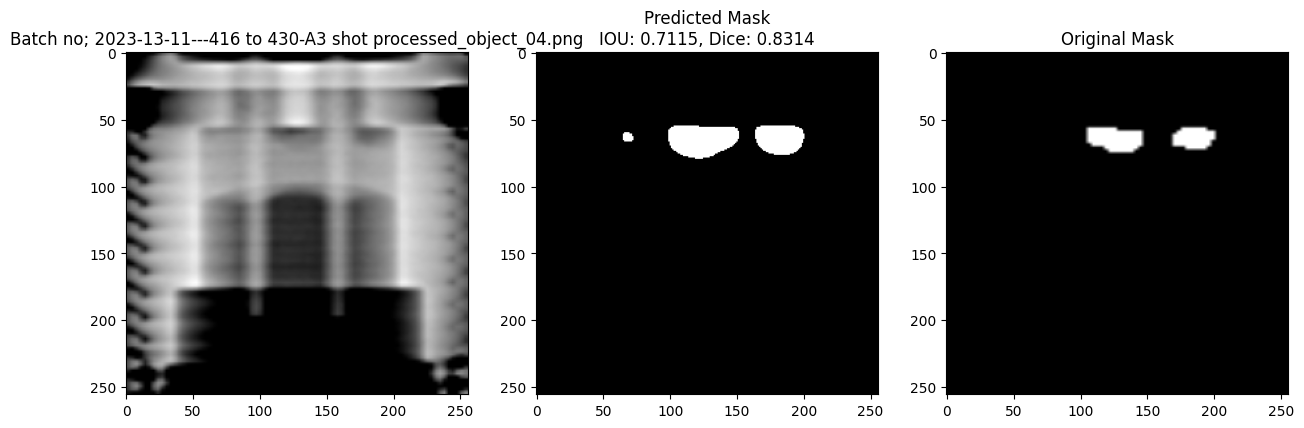

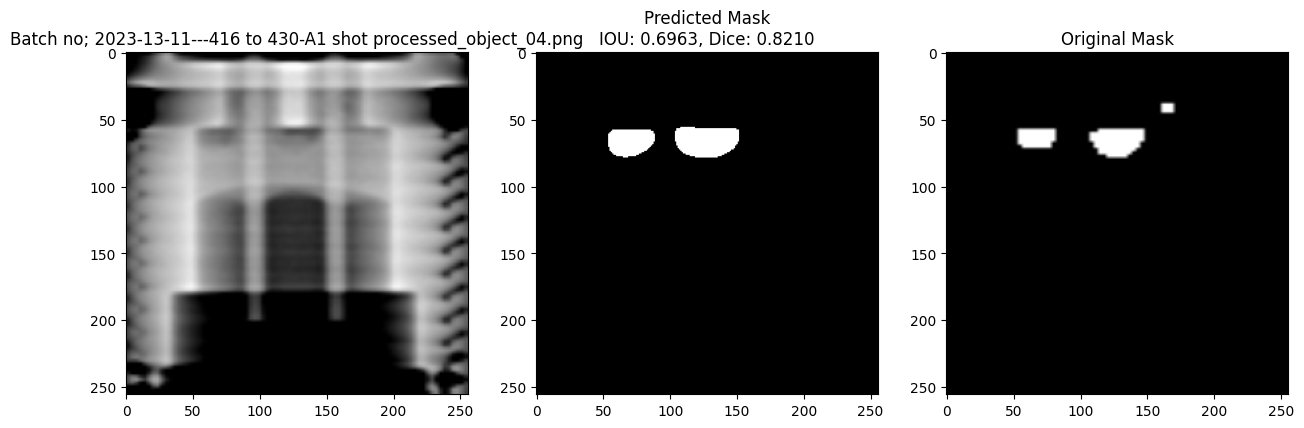

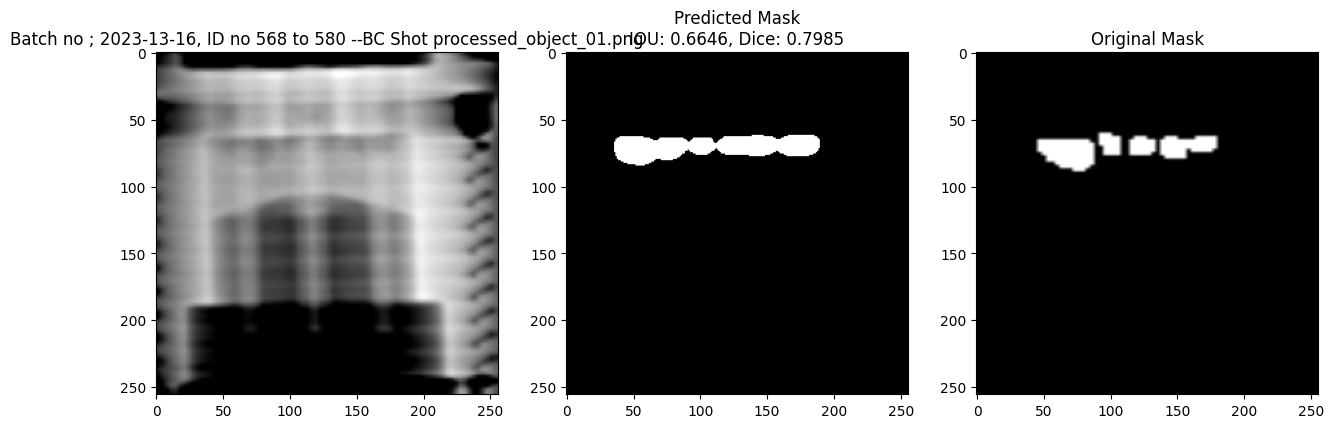

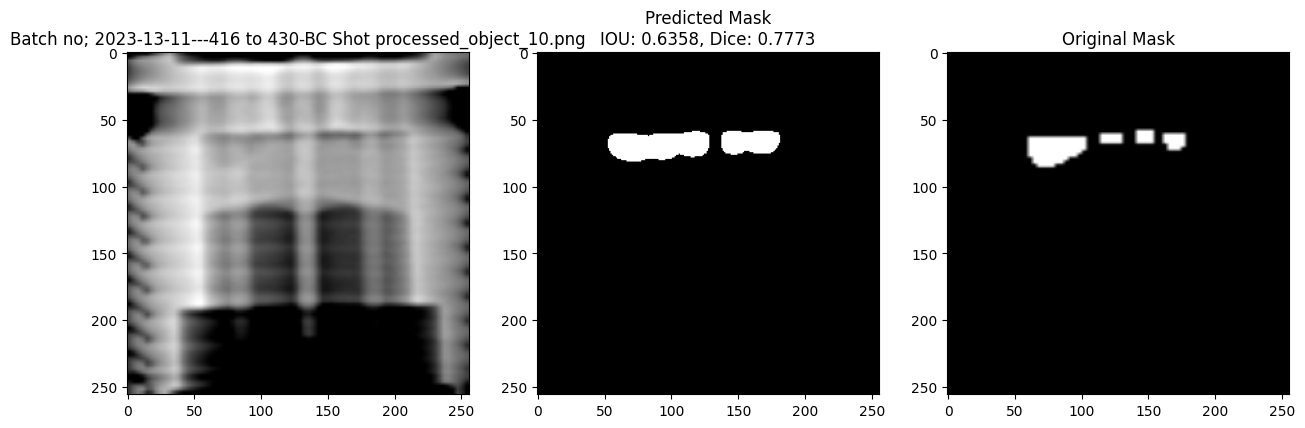

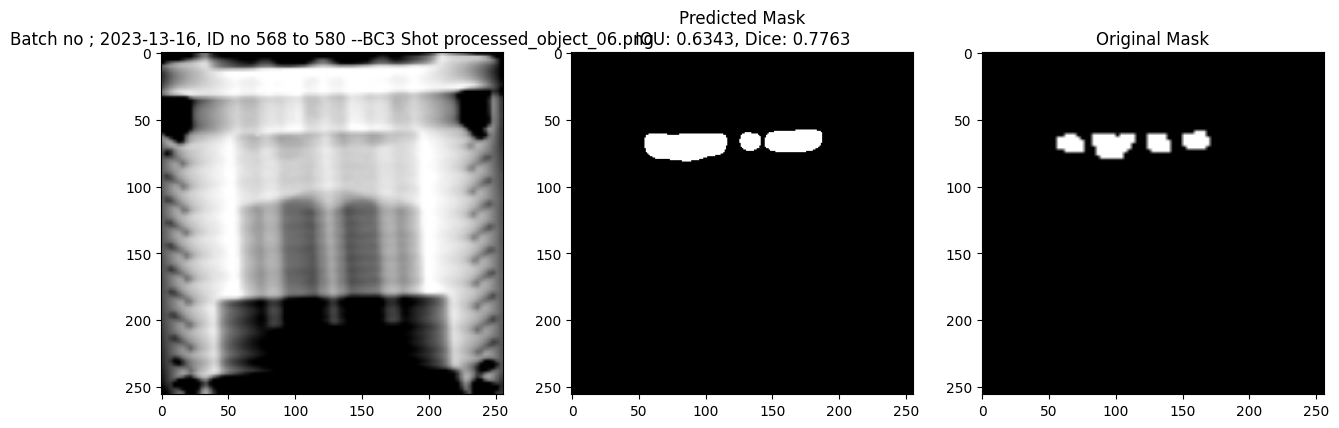

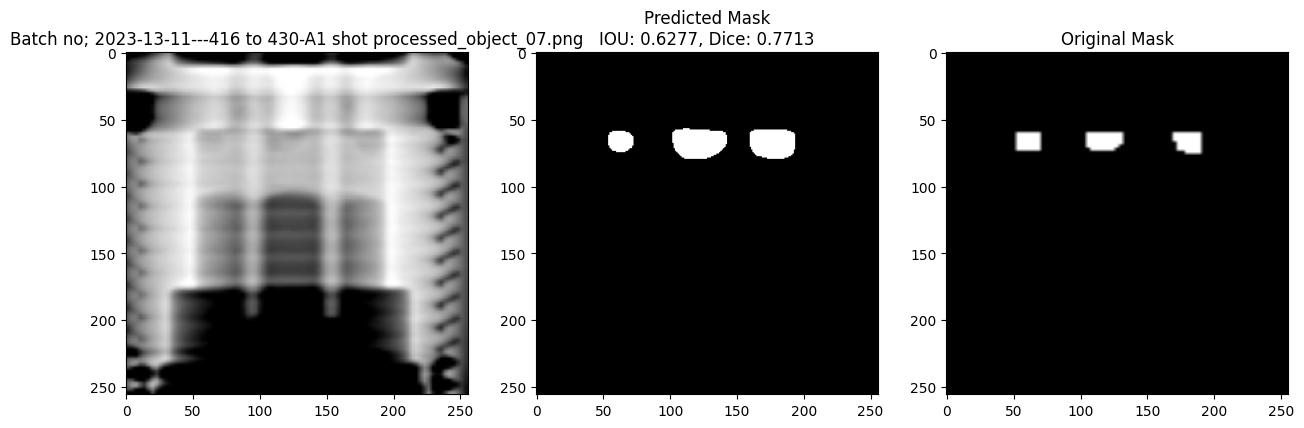

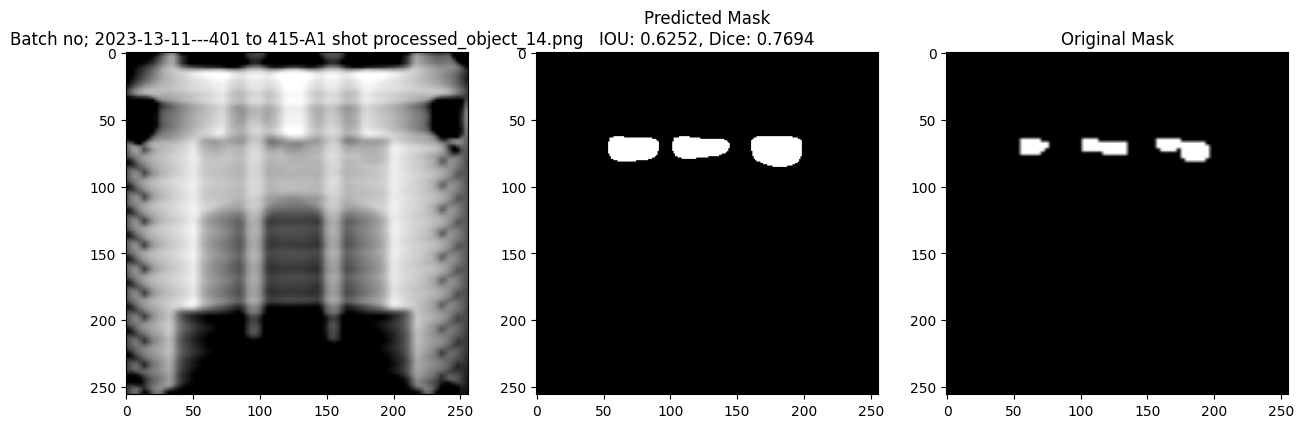

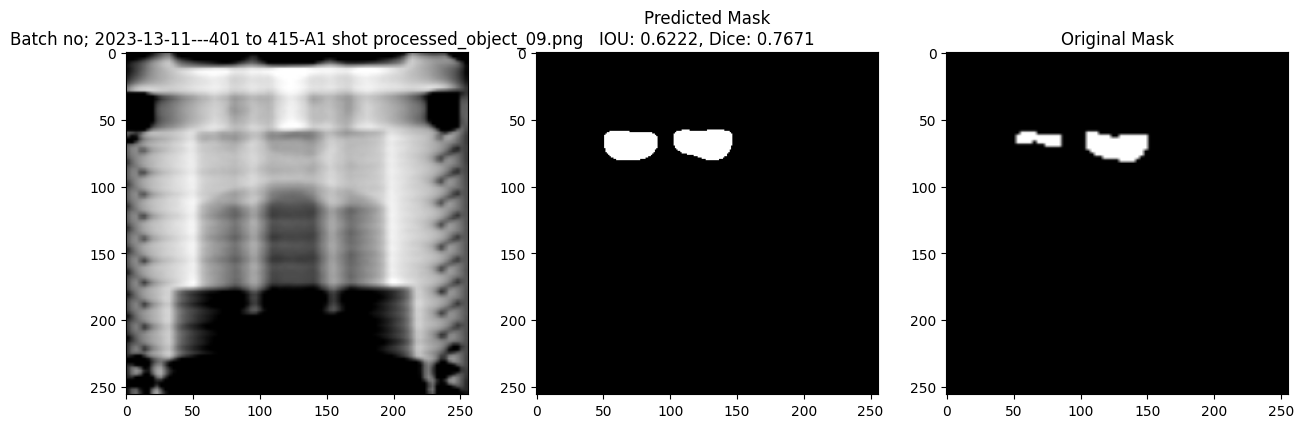

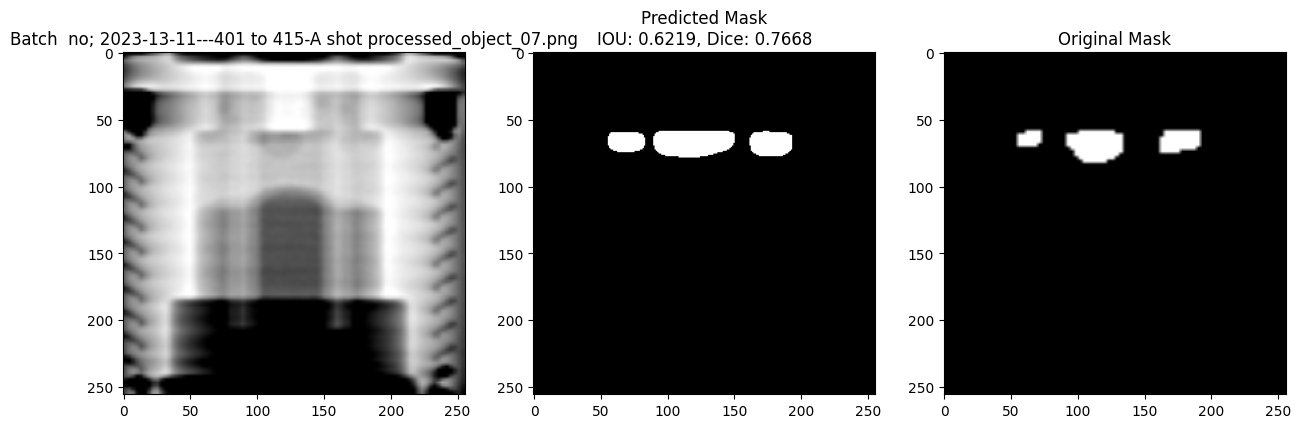

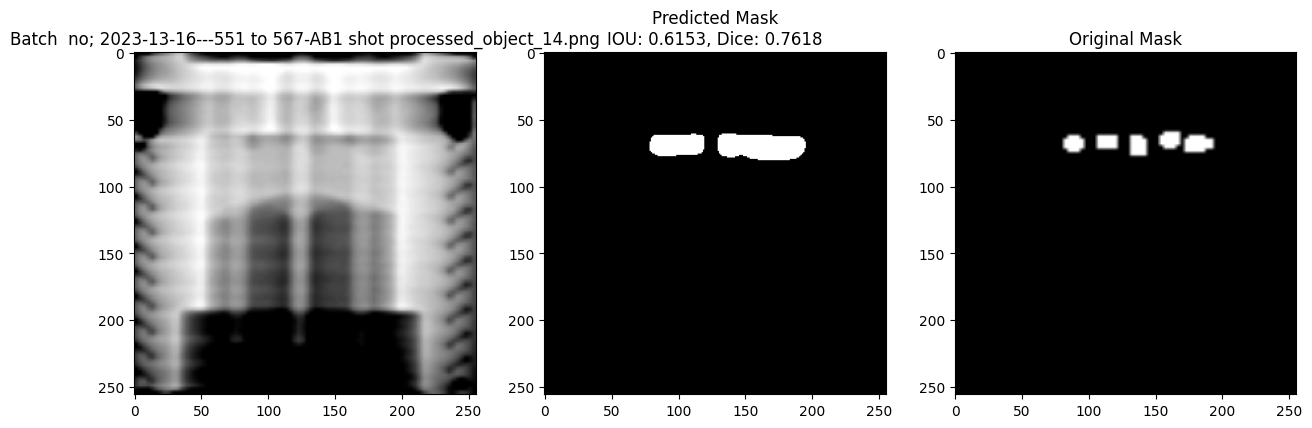

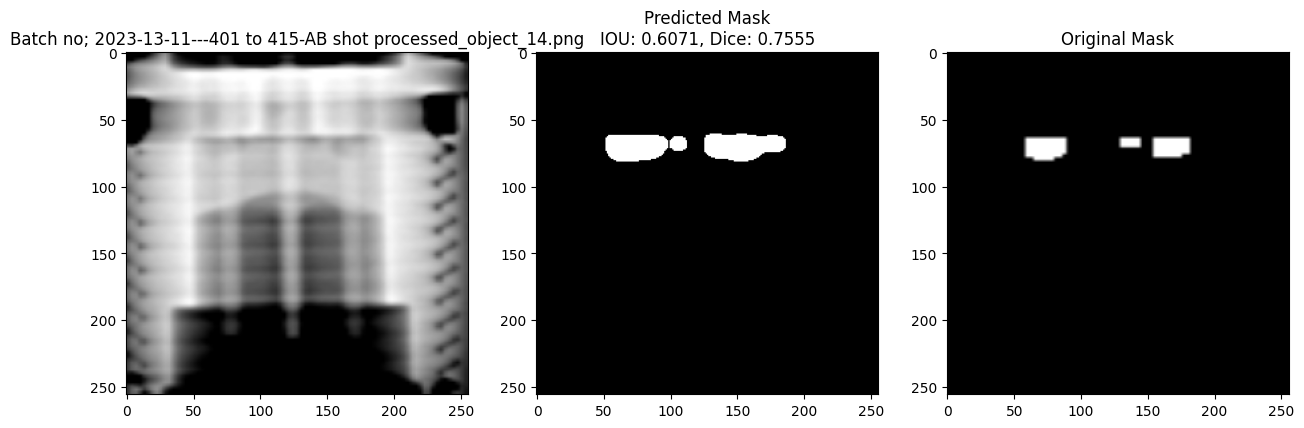

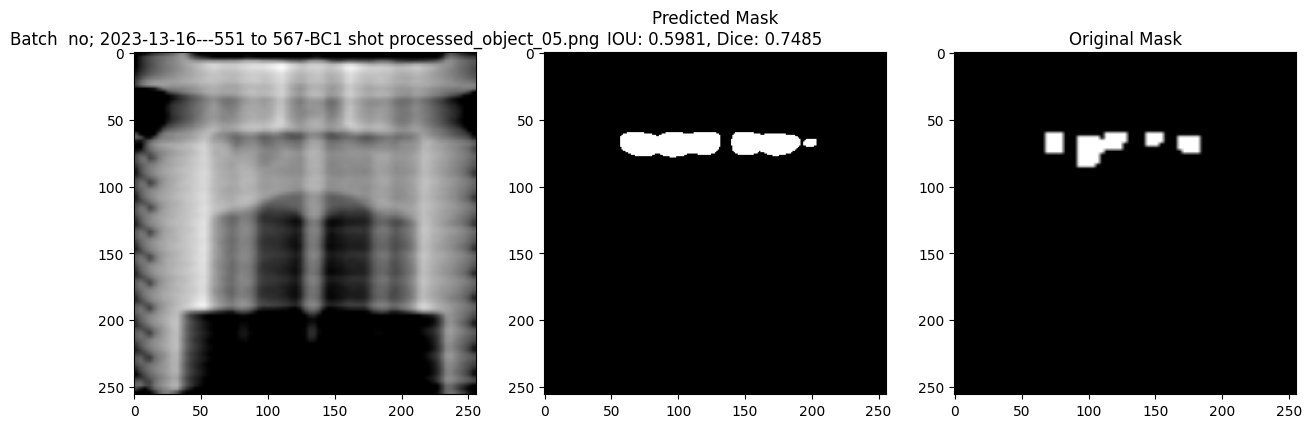

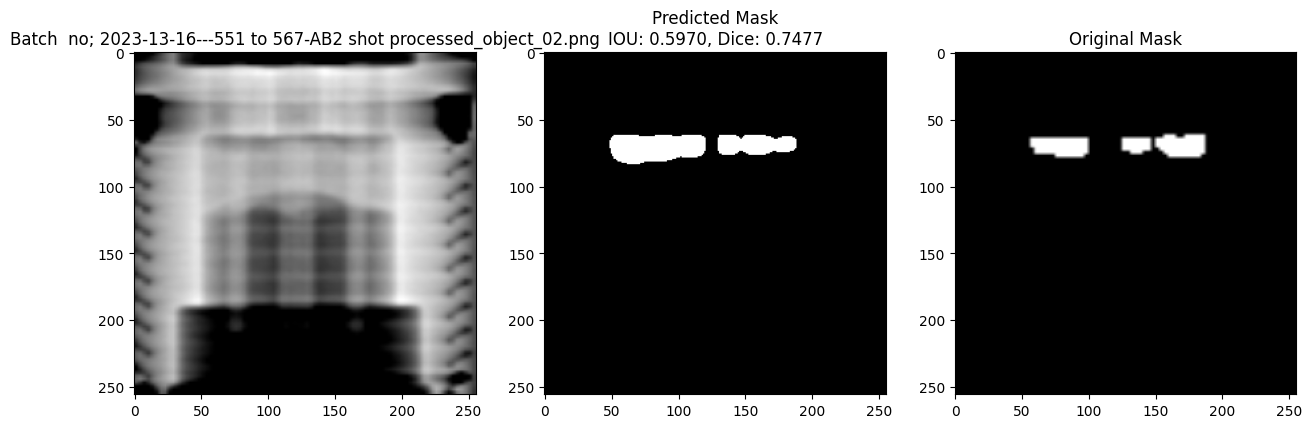

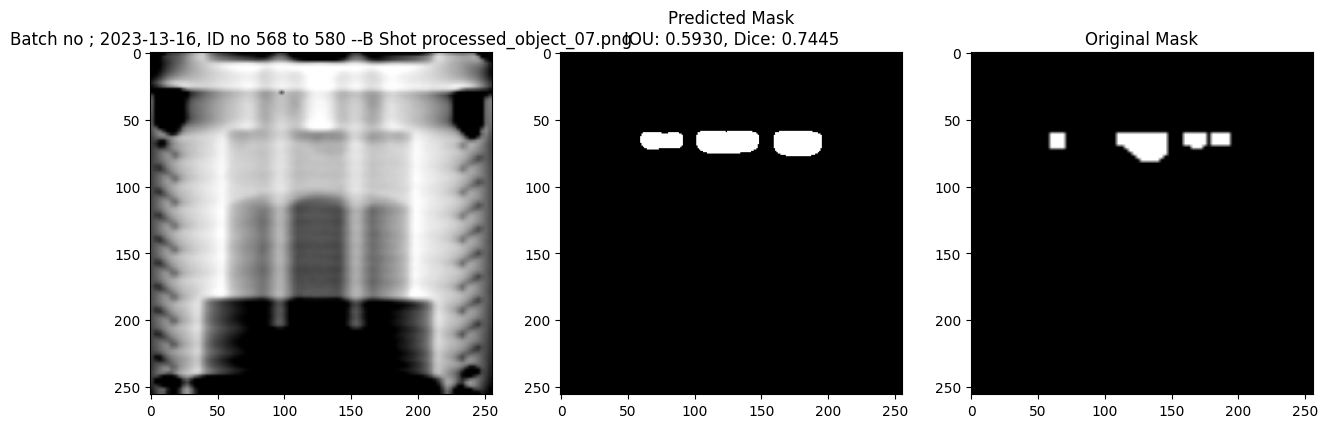

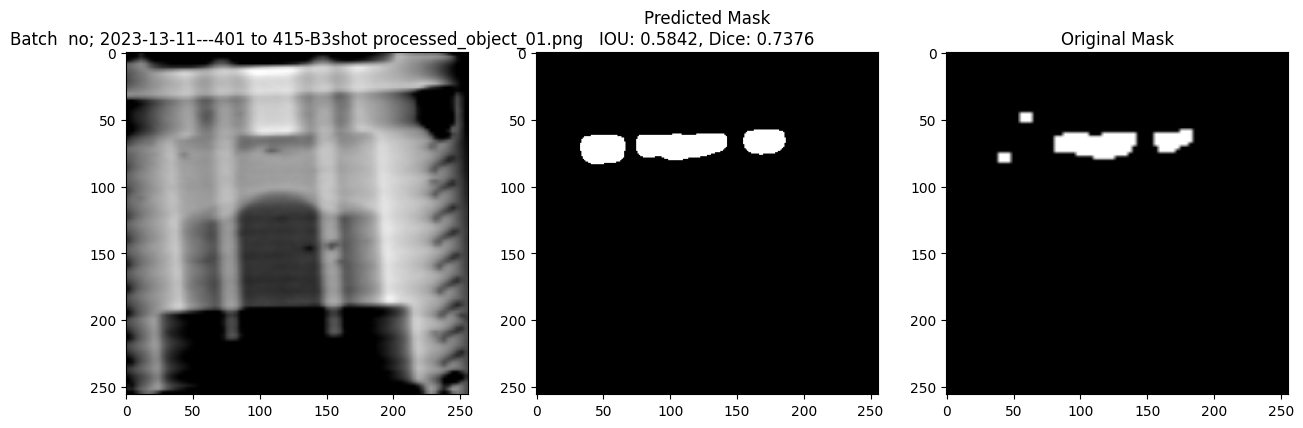

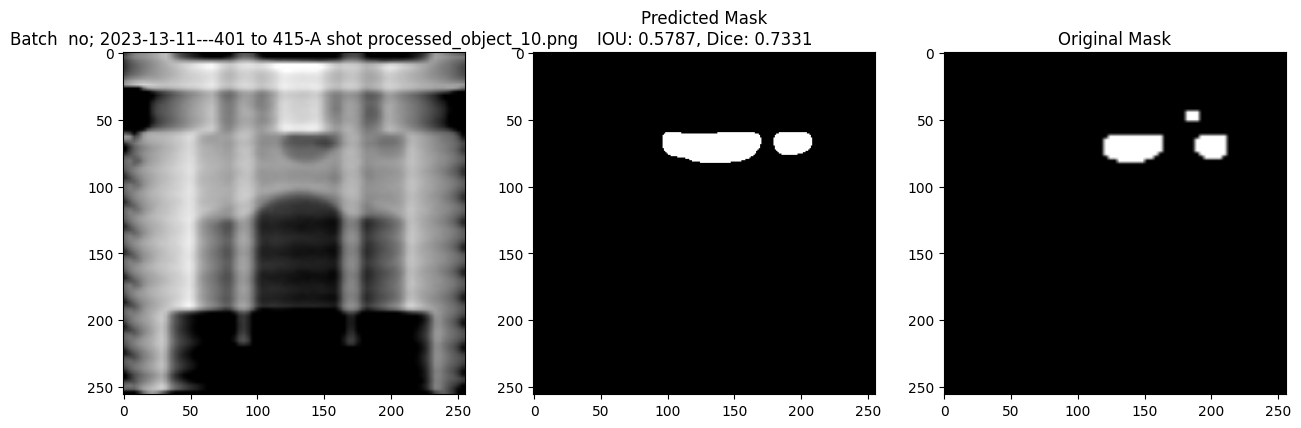

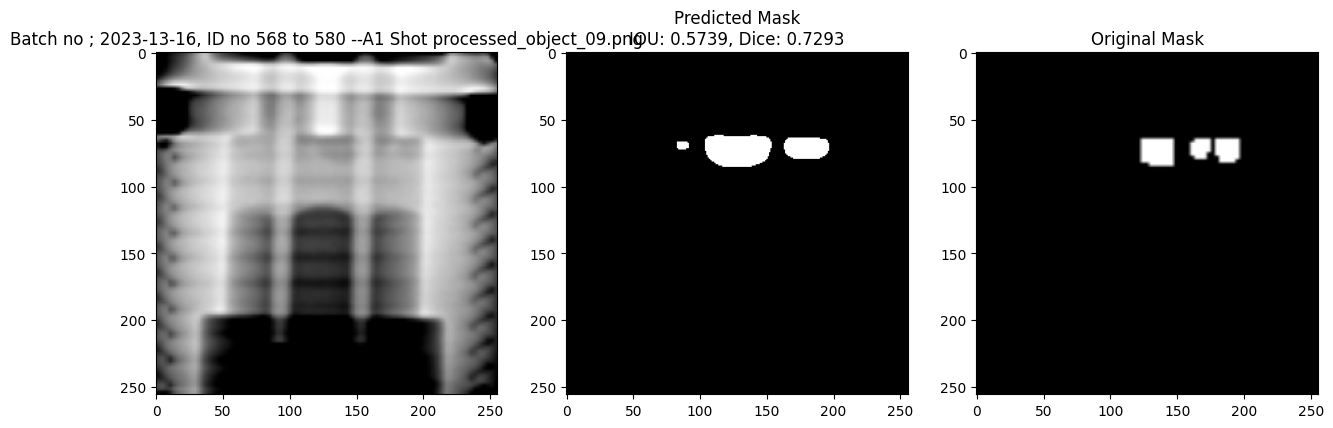

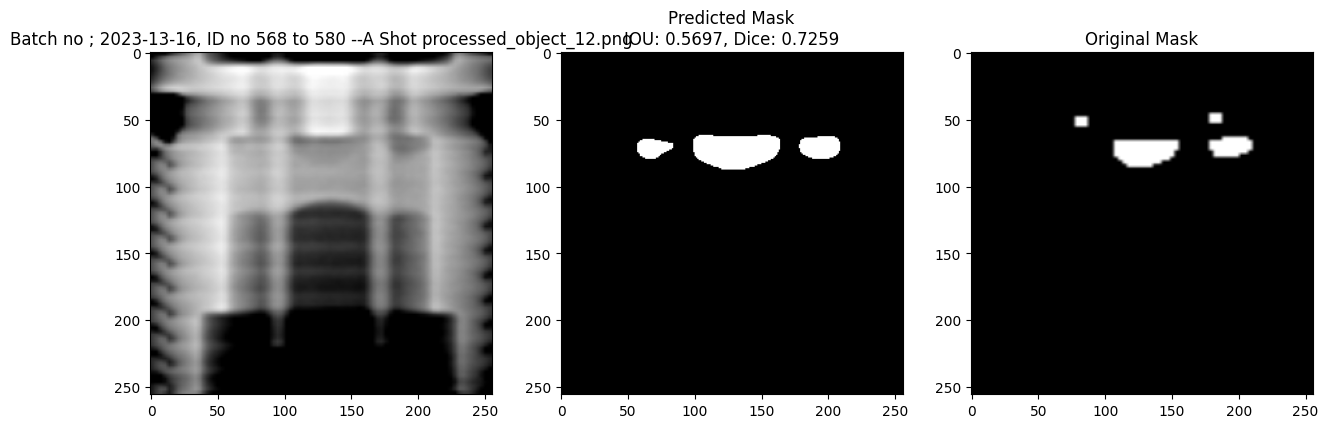

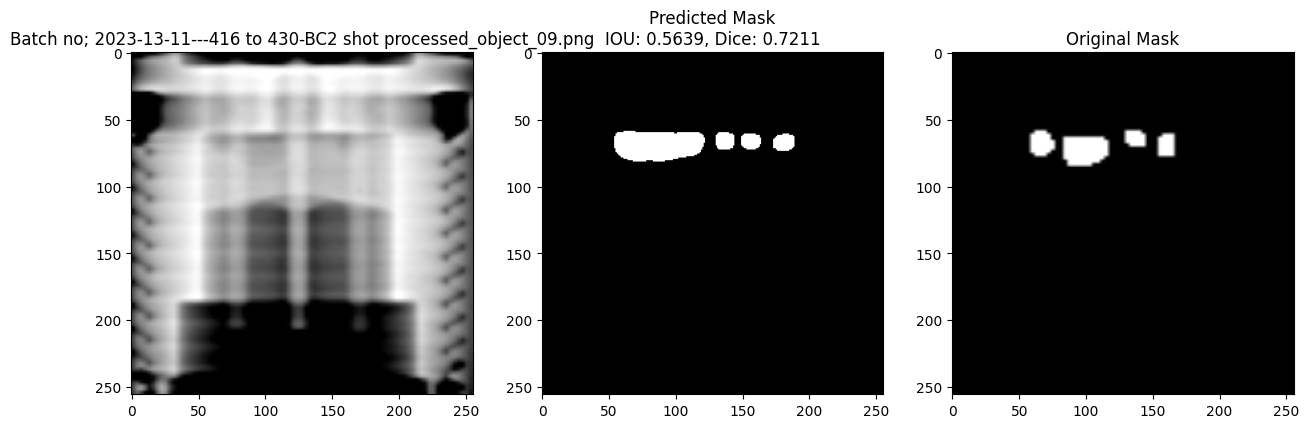

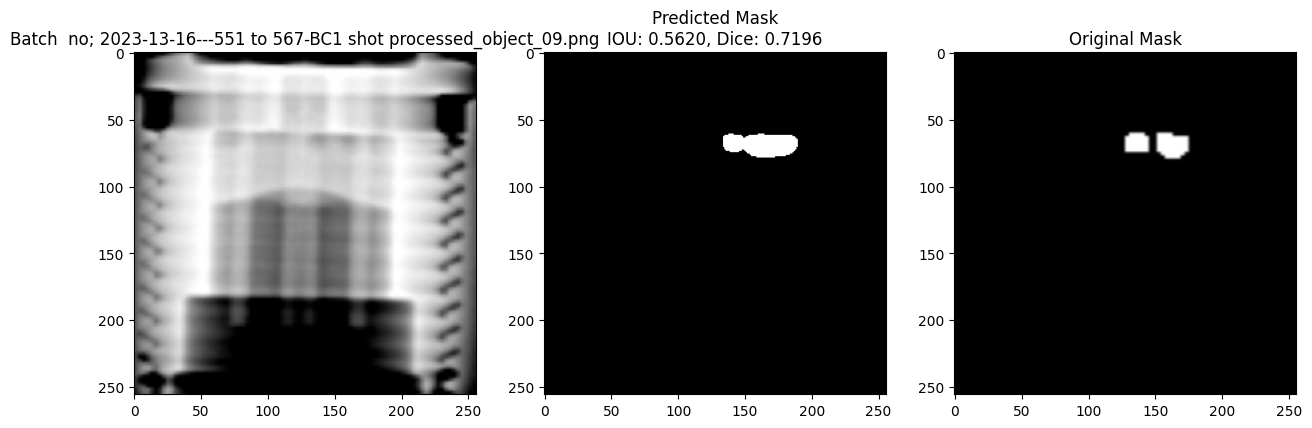

In [20]:
#For each of the worst results, visualize the predicted mask and the original mask side by side
for res in worst_results:
    img_name = res['image']
    img_path = os.path.join(val_images, img_name)
    mask_name = img_name.replace('.tiff', '.png')
    mask_path = os.path.join(val_masks, mask_name)

    image = Image.open(img_path)
    arr = np.array(image, dtype=np.float32)

    # Stretch to 0-255
    arr = (arr - arr.min()) / (arr.max() - arr.min()) * 255
    arr_uint8 = arr.astype(np.uint8)
    arr_uint8 = cv2.resize(arr_uint8, (256, 256))
    image = cv2.cvtColor(arr_uint8, cv2.COLOR_GRAY2BGR)
    pred_mask = res['mask']
    pred_mask = Image.fromarray((pred_mask * 255).astype(np.uint8))
    original_mask = Image.open(mask_path).convert('L')
    original_mask = resize(original_mask)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    # For the original image - show true grayscale without normalization
    axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'{img_name}')
    axes[1].imshow(pred_mask, cmap='gray')
    axes[1].set_title(f'Predicted Mask\nIOU: {res["iou"]:.4f}, Dice: {res["dice"]:.4f}')
    axes[2].imshow(original_mask, cmap='gray')
    axes[2].set_title('Original Mask')
    plt.show()

Batch no_ 2023-13-11---401 to 415-A1 shot_object_08.tiff → IoU: 0.397, Dice: 0.568


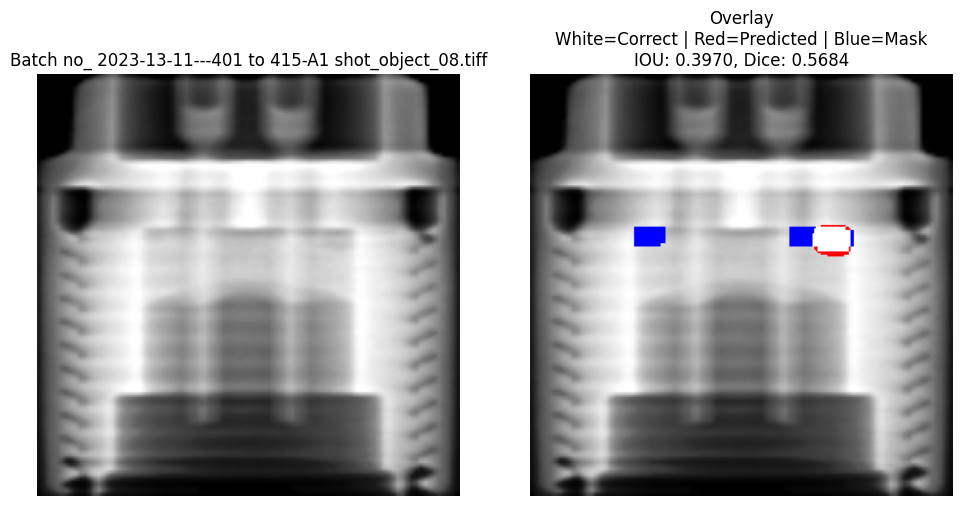

Batch  no_ 2023-13-16---551 to 567-B shot_object_01.tiff → IoU: 0.391, Dice: 0.563


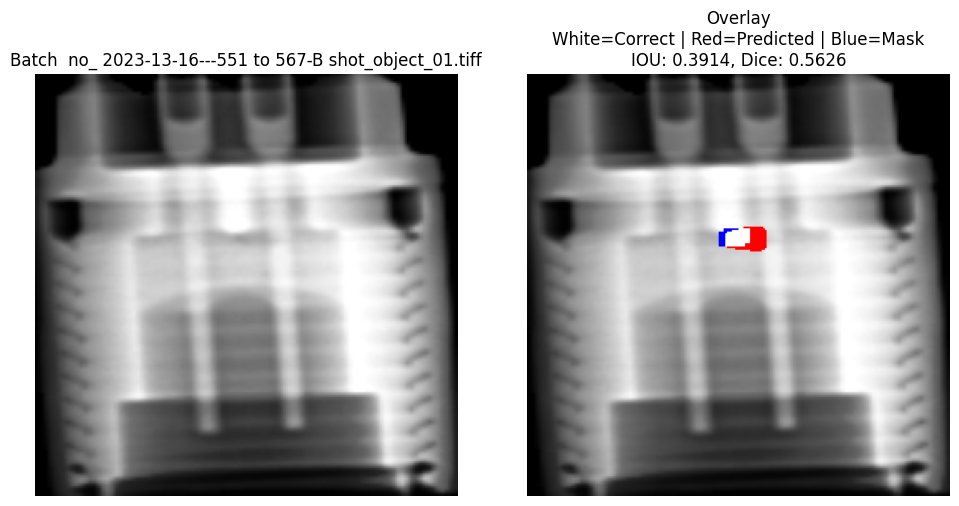

Batch  no_ 2023-13-16---551 to 567-A shot_object_01.tiff → IoU: 0.388, Dice: 0.559


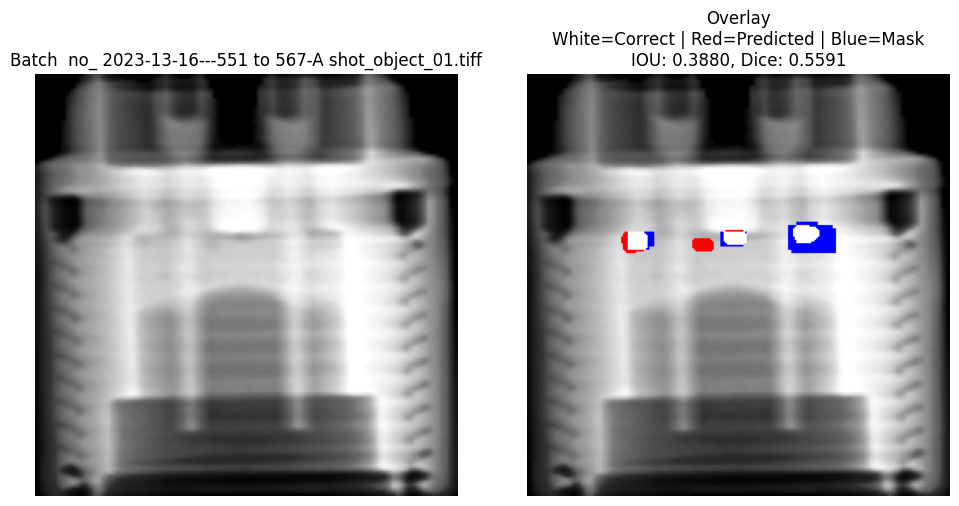

Batch no_ 2023-13-11---416 to 430-AB shot_object_09.tiff → IoU: 0.388, Dice: 0.559


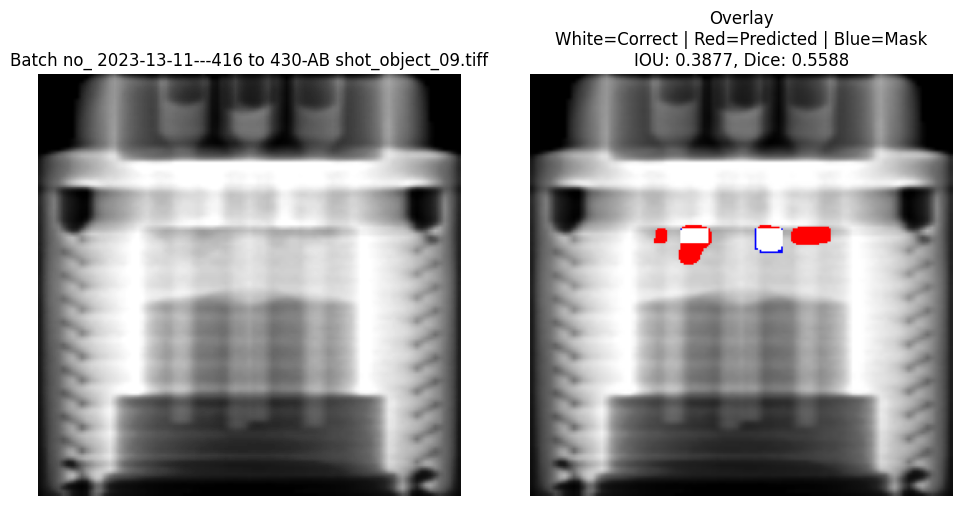

Batch no_ 2023-13-11---416 to 430-BC1 shot_object_12.tiff → IoU: 0.380, Dice: 0.551


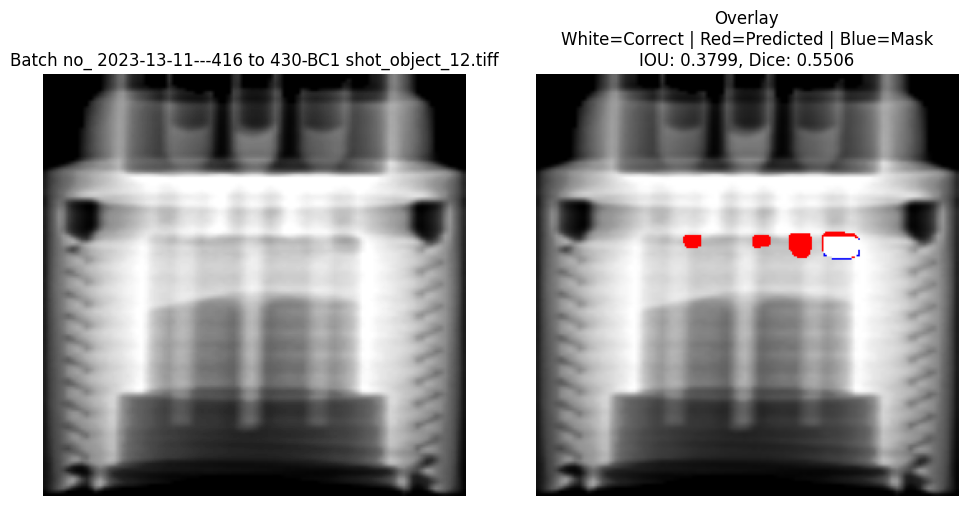

Batch no_ 2023-13-11---416 to 430-BC3 shot_object_12.tiff → IoU: 0.360, Dice: 0.530


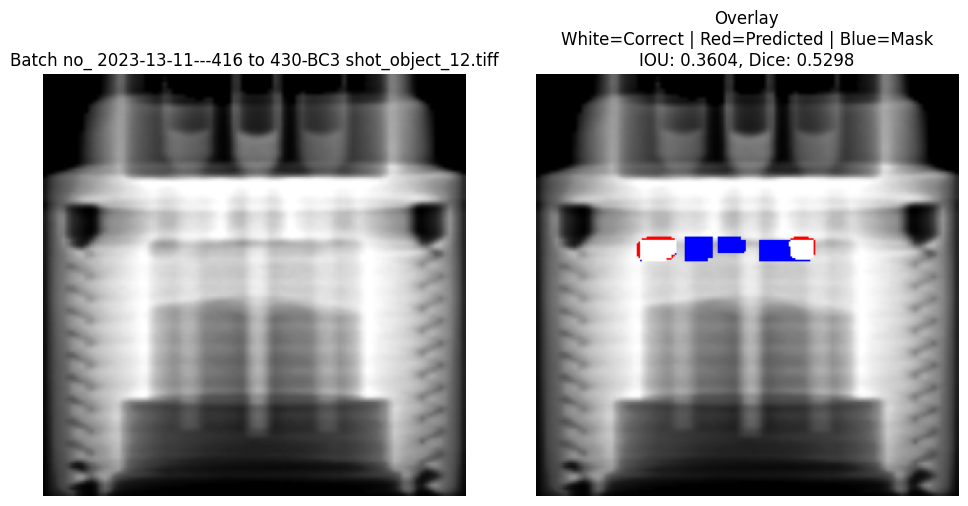

Batch  no_ 2023-13-16---551 to 567-AB shot_object_11.tiff → IoU: 0.356, Dice: 0.525


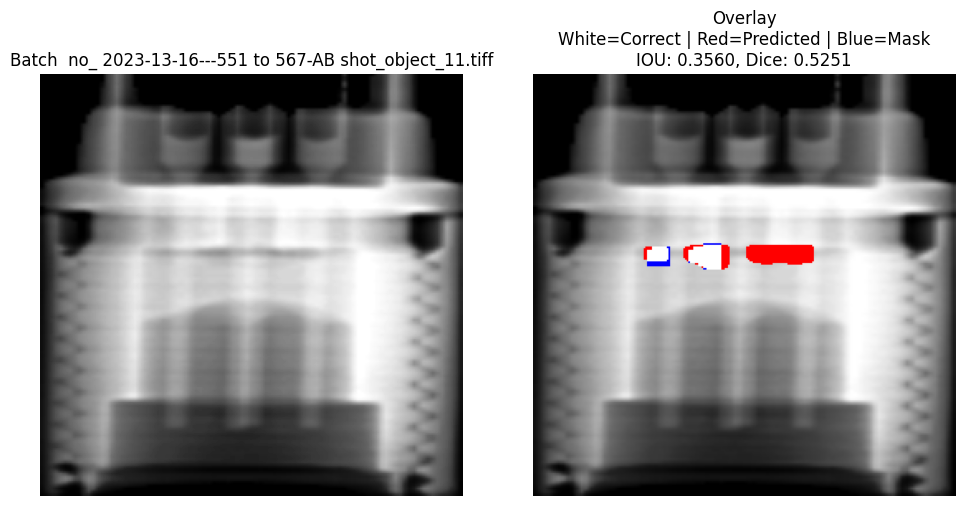

Batch  no_ 2023-13-16---551 to 567-A3 shot_object_01.tiff → IoU: 0.335, Dice: 0.502


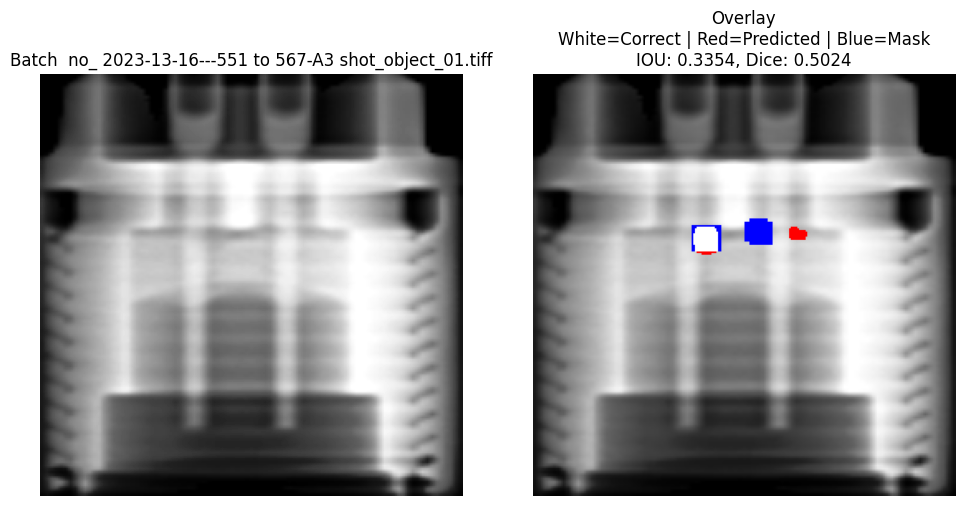

Batch no _ 2023-13-16, ID no 568 to 580 --B3 Shot_object_07.tiff → IoU: 0.312, Dice: 0.476


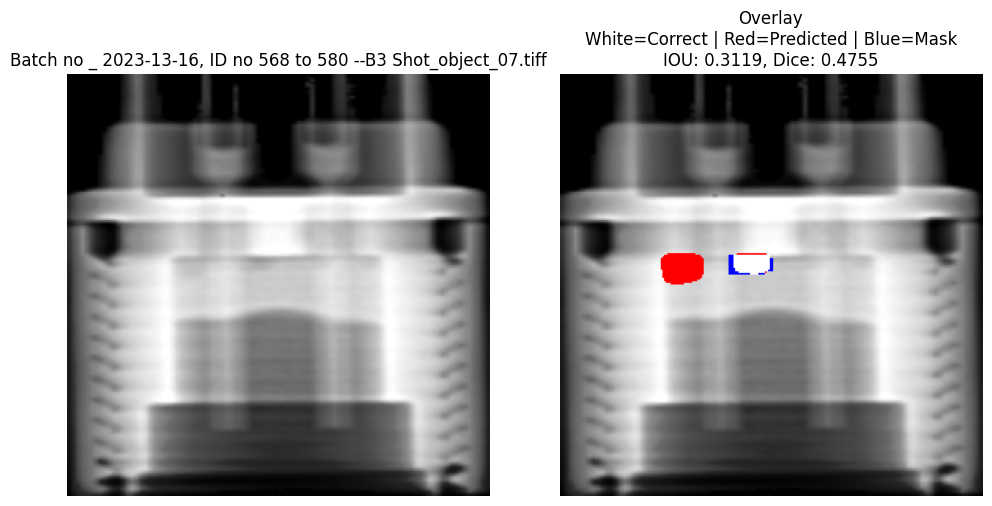

Batch  no_ 2023-13-16---551 to 567-A1 shot_object_15.tiff → IoU: 0.306, Dice: 0.469


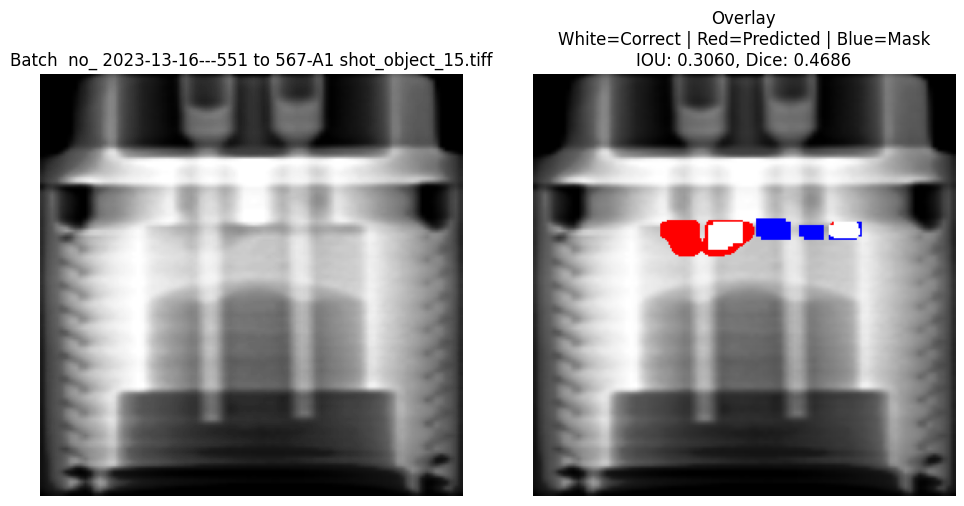

Batch  no_ 2023-13-16---551 to 567-BC shot_object_12.tiff → IoU: 0.286, Dice: 0.445


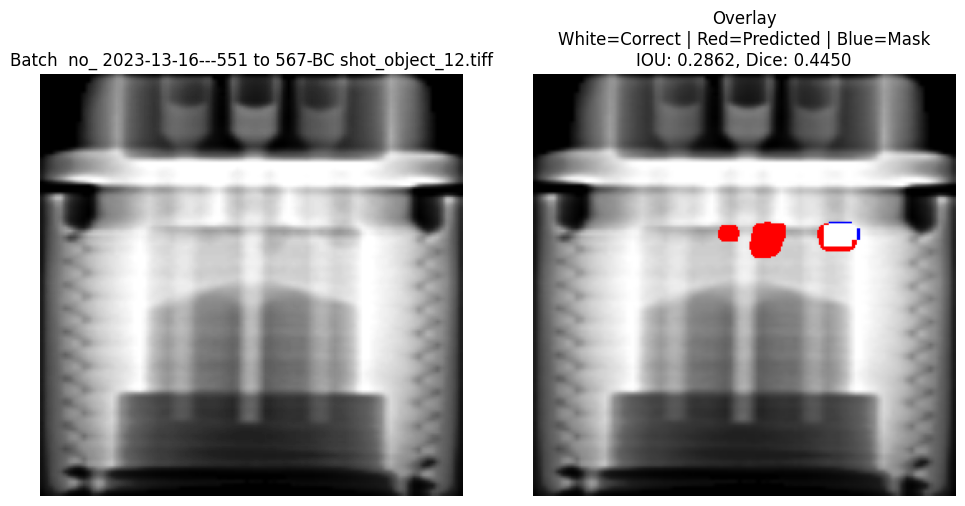

Batch no_ 2023-13-11---401 to 415-BC shot_object_11.tiff → IoU: 0.278, Dice: 0.435


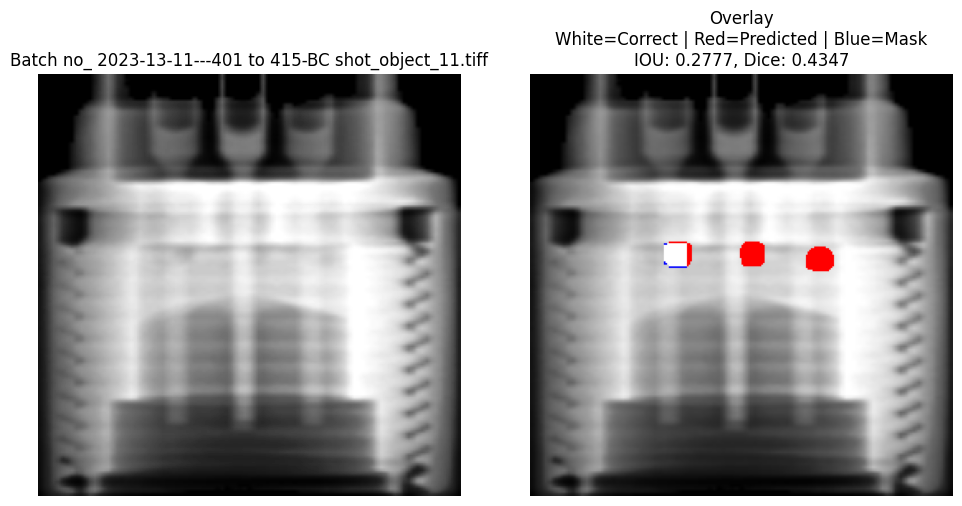

Batch  no_ 2023-13-11---401 to 415-AB3 shot_object_12.tiff → IoU: 0.228, Dice: 0.371


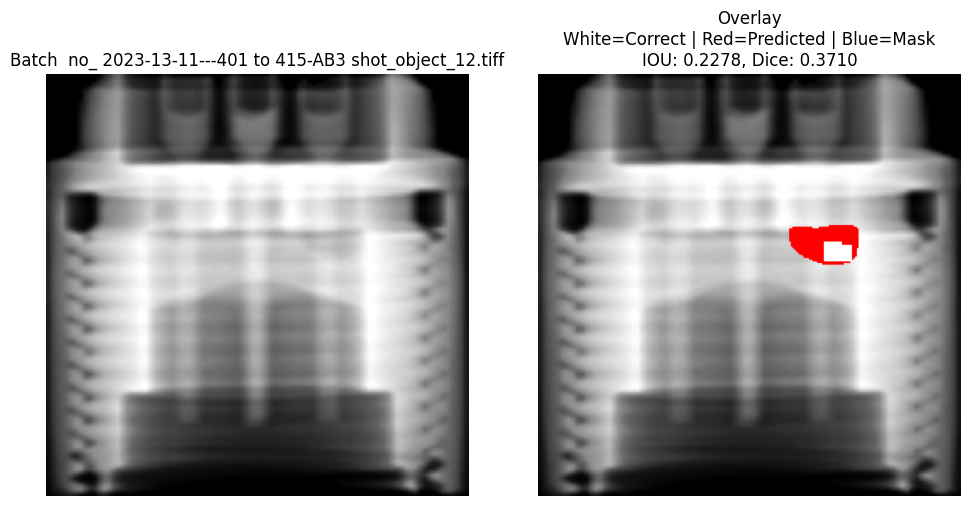

Batch  no_ 2023-13-16---551 to 567-BC2 shot_object_04.tiff → IoU: 0.182, Dice: 0.308


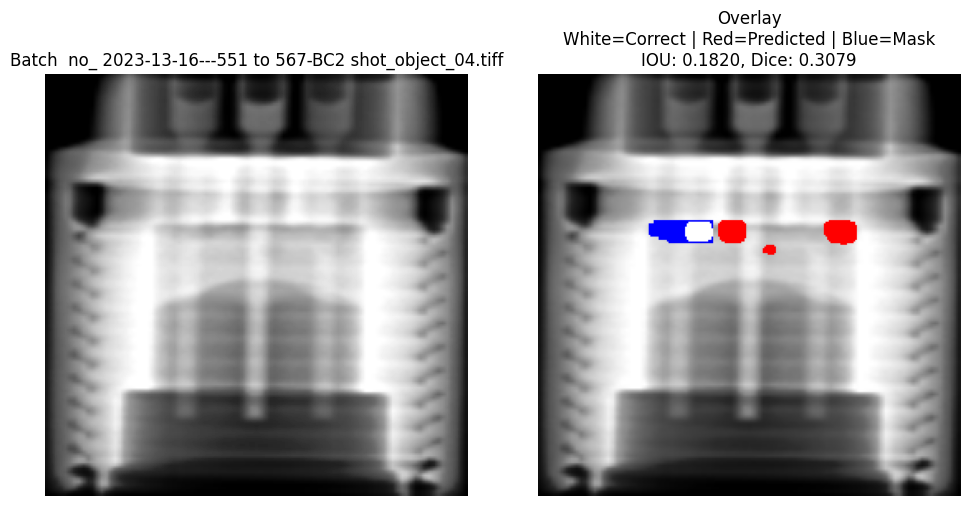

Batch no_ 2023-13-11---401 to 415-BC shot_object_08.tiff → IoU: 0.000, Dice: 0.000


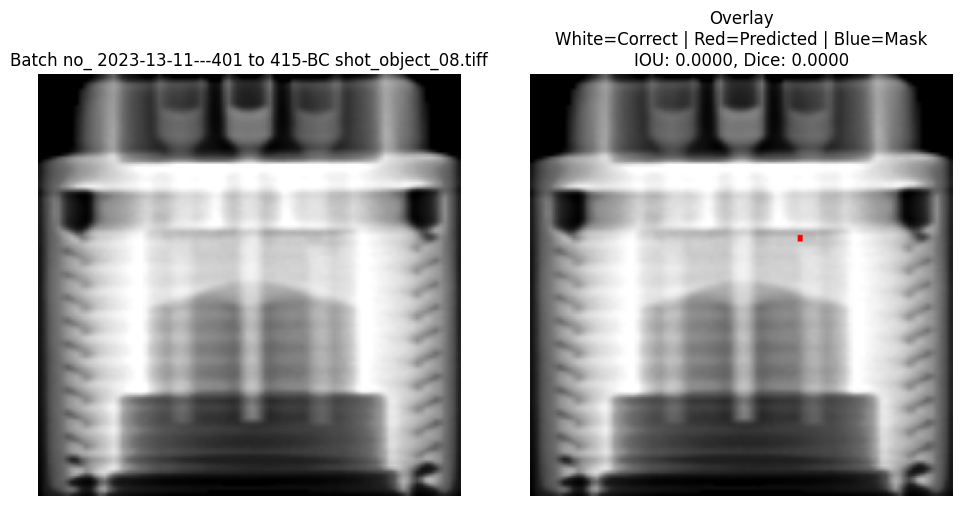

Batch  no_ 2023-13-16---551 to 567-BC3 shot_object_03.tiff → IoU: 0.000, Dice: 0.000


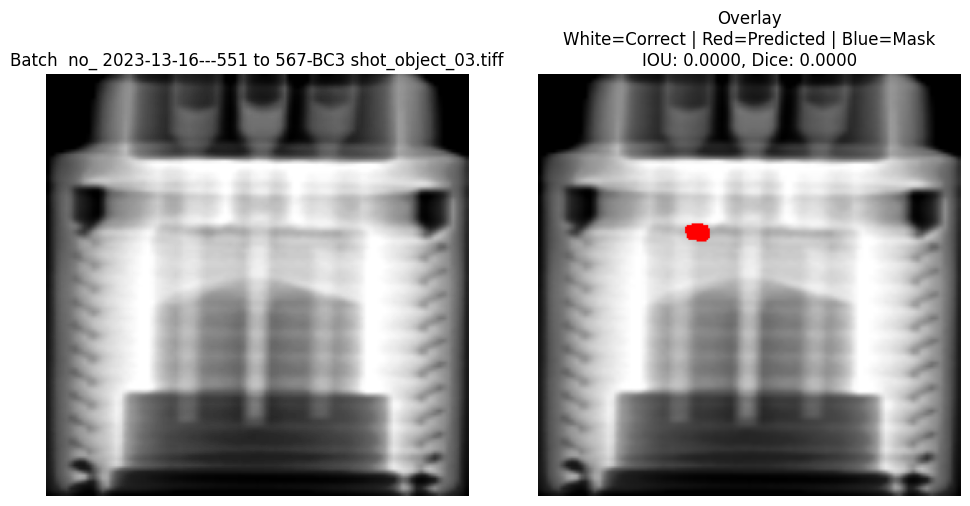

Batch no_ 2023-13-11---416 to 430-AB3 shot_object_14.tiff → IoU: 0.000, Dice: 0.000


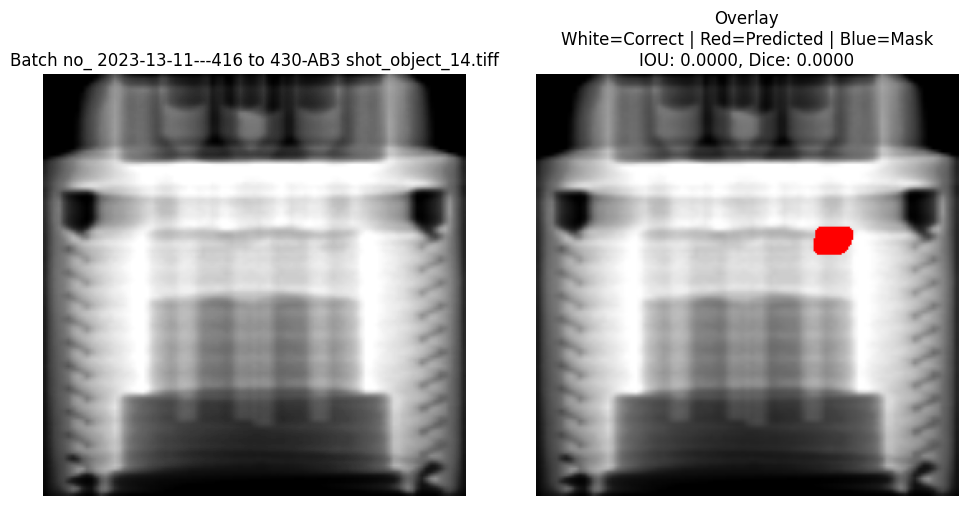

Batch  no_ 2023-13-16---551 to 567-BC2 shot_object_02.tiff → IoU: 0.000, Dice: 0.000


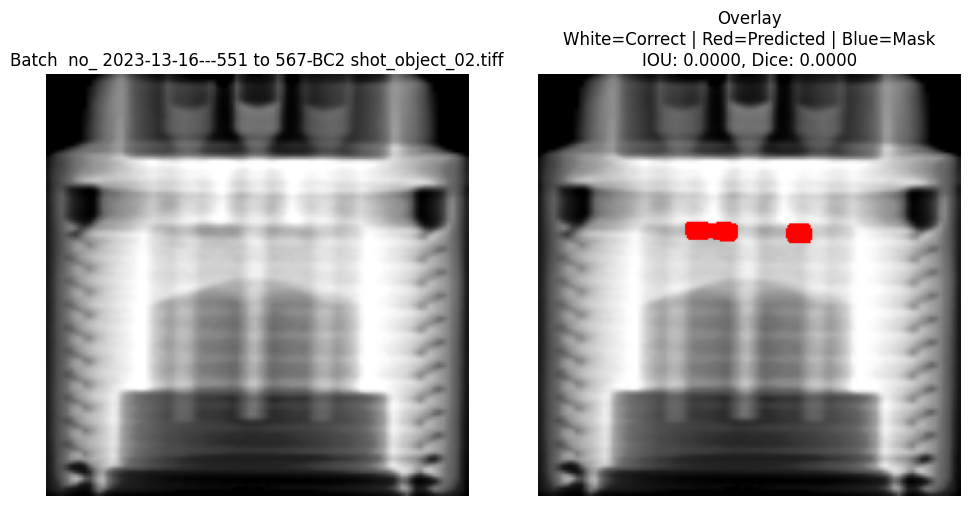

Batch  no_ 2023-13-16---551 to 567-BC shot_object_01.tiff → IoU: 0.000, Dice: 0.000


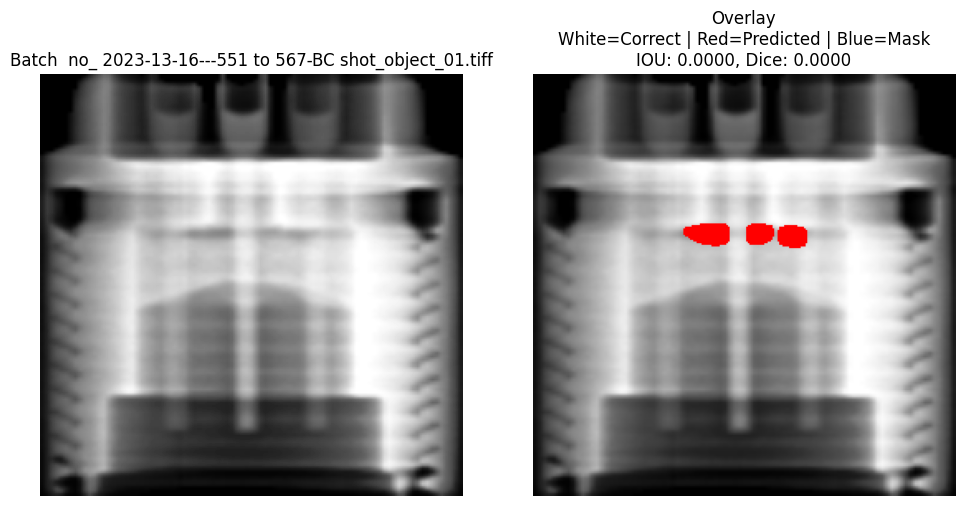

Batch  no_ 2023-13-16---551 to 567-AB1 shot_object_01.tiff → IoU: 0.000, Dice: 0.000


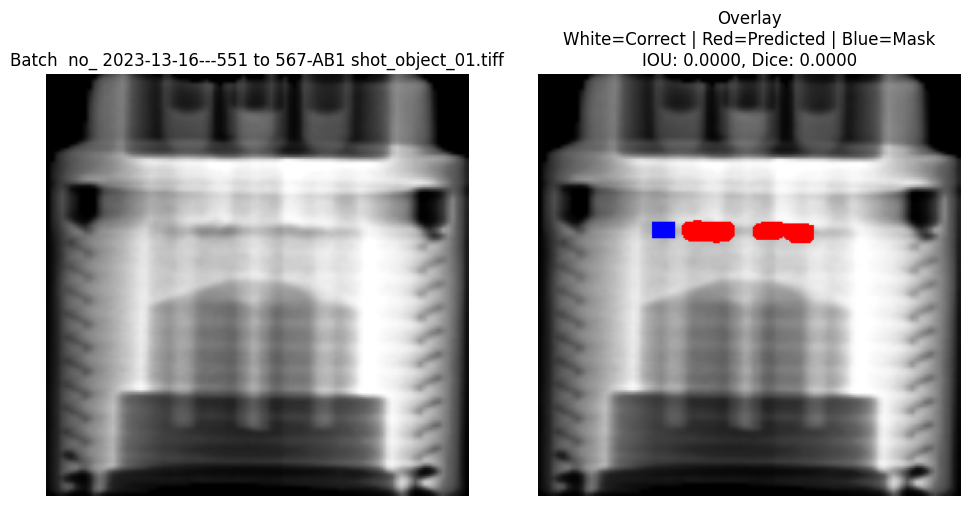

In [21]:
# For the worst performing images, visualize with error-aware overlay
for res in worst_results:
    img_name = res['image']
    img_path = os.path.join(val_images, img_name)
    mask_name = img_name.replace('.tiff', '.png')
    mask_path = os.path.join(val_masks, mask_name)

    image = Image.open(img_path).convert('L')
    image = resize(image)

    # Convert to numpy
    image_np = np.array(image)

    pred_mask = res['mask']  # should be 0/1 numpy

    original_mask = Image.open(mask_path).convert('L')
    original_mask = resize(original_mask)
    original_mask = np.array(original_mask)
    original_mask = (original_mask > 0).astype(np.uint8)

    # Create RGB overlay
    overlay = np.stack([image_np]*3, axis=-1)

    # --- Error breakdown ---
    # True Positive (correct prediction)
    tp = (pred_mask == 1) & (original_mask == 1)

    # False Positive (over-prediction)
    fp = (pred_mask == 1) & (original_mask == 0)

    # False Negative (missed regions)
    fn = (pred_mask == 0) & (original_mask == 1)

    # Apply colors
    overlay[tp] = [255, 255, 255]  # White → correct
    overlay[fp] = [255, 0, 0]      # Red → false positive
    overlay[fn] = [0, 0, 255]      # Blue → false negative

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    print(f"{img_name} → IoU: {res['iou']:.3f}, Dice: {res['dice']:.3f}")
    axes[0].imshow(image_np, cmap='gray')
    axes[0].set_title(f'{img_name}')
    axes[0].axis('off')

    axes[1].imshow(overlay)
    axes[1].set_title(
        f'Overlay\nWhite=Correct | Red=Predicted | Blue=Mask\n'
        f'IOU: {res["iou"]:.4f}, Dice: {res["dice"]:.4f}'
    )
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [1]:
file_name = "Batch no _ 2023-13-16, ID no 568 to 580 --A Shot_object_12"
threshold = 0.25
#Run the model inference on this image and visualize the predicted mask and the original mask
img_path = os.path.join(val_images, file_name + '.tiff')
image = Image.open(img_path).convert('L')
image = resize(image)
image_tensor = TF.to_tensor(image)
image_tensor = TF.normalize(image_tensor, mean=[0.485], std=[0.229])
image_tensor = image_tensor.unsqueeze(0).to(device)
with torch.no_grad():
    output = model(image_tensor)
    pred_mask = torch.sigmoid(output).cpu()  # keep as tensor
    pred_mask = (pred_mask > threshold).float()
    kernel = np.ones((3,3), np.uint8)
    pred_mask = cv2.dilate(pred_mask.numpy().squeeze(), kernel)
    pred_mask = torch.from_numpy(pred_mask).unsqueeze(0).unsqueeze(0).float()  # back to tensor with shape [1, 1, H, W]
# Load mask
mask_name = file_name + '.png'
mask_path = os.path.join(val_masks, mask_name)
original_mask = Image.open(mask_path).convert('L')
original_mask = resize(original_mask)
original_mask = TF.to_tensor(original_mask)  # stays tensor
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(image_tensor.cpu().squeeze(), cmap='gray')
axes[0].set_title(file_name)
# axes[1].imshow(pred_mask.cpu().squeeze(), cmap='gray')
# axes[1].set_title('Predicted Mask')
axes[1].imshow(original_mask.cpu().squeeze(), cmap='gray')
axes[1].set_title('Original Mask')
plt.show()

NameError: name 'os' is not defined